In [1]:
# 24.08.2026, wieczor (kontynuacja) - Maciek zauwazyl, ze moj poprzedni
# wykres (20260824d.ipynb) NIE probowal replikowac Fig. 4 z artykulu, tylko
# nakladal tekstowo podane daty na nasza wlasna krzywa z osia X = t0
# (poczatek okna). Sprawdzenie prawdziwego Fig. 4 (strona 6 PDF,
# zrodla/GlownyArtykul.pdf) potwierdzilo centralny zarzut Opusa wprost z
# podpisu: "with the curve points located at the CENTERS of the windows".
#
# Ten notebook: przerysowac NASZA WLASNA, juz policzona krzywa Moskwy (dt=0,
# P w {1675, 3350}, d=5) na osi X = t0 + P/2 (konwencja artykulu) i
# zestawic WIZUALNIE, bok w bok, z prawdziwym obrazkiem Fig. 4 (wyciety z
# PDF-a przez pdftoppm+PIL, zapisany jako
# zrodla/GlownyArtykul_Fig4.png - referencyjny wycinek zrodla, nie wynik
# naszej analizy). Dodatkowo nakladka liczby plam slonecznych (SN_m_tot_
# V2.0.csv, wygladzenie 13-miesieczne jak w podpisie Fig.4 - NIE LOWESS,
# ktorego uzywalismy do wykrywania granic cykli w innych notebookach, to
# inny cel).
#
# WAZNE zastrzezenie: to ciagle dt=0 (nasza dotychczasowa konwencja "no
# lag"), NIE dt=15 jak w przepisie artykulu - z 20260824d.ipynb wiemy, ze
# to zanizy GLEBOKOSC dopasowania dla czesci punktow. Tu testujemy przede
# wszystkim KSZTALT/POZYCJE dolkow, nie dokladne wartosci PPDF. Zero
# nowych obliczen (wszystko z juz policzonych plikow cycle_scan_mosc_*).
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.image import imread
from scipy.signal import find_peaks

RESULTS_DIR = "../results"
SUNSPOT_PATH = "../data/SN_m_tot_V2.0.csv"
FIG4_REFERENCE_PATH = "../źródła/GlownyArtykul_Fig4.png"


def to_decimal_year(t0_series):
    year_start = pd.to_datetime(t0_series.dt.year.astype(str) + "-01-01")
    year_end = pd.to_datetime((t0_series.dt.year + 1).astype(str) + "-01-01")
    frac = (t0_series - year_start) / (year_end - year_start)
    return t0_series.dt.year + frac

In [2]:
# KROK 1: sklejenie juz policzonych plikow cycle_scan_mosc_*_P{1675,3350}_
# d5.csv (dt=0) w dwie ciagle krzywe PPDF-vs-t0 (Moskwa).
def load_stitched(P_days):
    frames = []
    for path in sorted(glob.glob(os.path.join(RESULTS_DIR, f"cycle_scan_mosc_cycle_*_P{P_days}_d5.csv"))):
        df = pd.read_csv(path, usecols=["t0", "PPDF"], parse_dates=["t0"]).dropna(subset=["PPDF"])
        frames.append(df)
    curve = pd.concat(frames, ignore_index=True).sort_values("t0").reset_index(drop=True)
    return curve


curve_1675 = load_stitched(1675)
curve_3350 = load_stitched(3350)
print(f"P=1675: {len(curve_1675)} punktow, {curve_1675['t0'].min()} .. {curve_1675['t0'].max()}")
print(f"P=3350: {len(curve_3350)} punktow, {curve_3350['t0'].min()} .. {curve_3350['t0'].max()}")

P=1675: 20275 punktow, 1965-01-02 00:00:00 .. 2020-07-01 00:00:00
P=3350: 18599 punktow, 1965-01-02 00:00:00 .. 2015-11-30 00:00:00


In [3]:
# KROK 2: przesuniecie na "srodek okna" (t0 + P/2, konwencja Fig.4) +
# wczytanie plam slonecznych z wygladzeniem 13-miesiecznym (dokladnie jak w
# legendzie Fig.4 - "smoothed over 13 months" - prosta srednia krocząca,
# NIE LOWESS, ktorego uzywalismy gdzie indziej do wykrywania granic cykli).
for curve, P_days in [(curve_1675, 1675), (curve_3350, 3350)]:
    curve["t0_center"] = curve["t0"] + pd.Timedelta(days=P_days / 2)
    curve["year_center"] = to_decimal_year(curve["t0_center"])

sunspot = pd.read_csv(SUNSPOT_PATH, sep=";")
sunspot.columns = [c.strip() for c in sunspot.columns]
sunspot["rok_norm"] = sunspot["rok_norm"].astype(float)
sunspot["sunspot"] = sunspot["sunspot"].astype(float)
sunspot = sunspot[(sunspot["rok_norm"] >= 1958) & (sunspot["rok_norm"] <= 2022)].sort_values("rok_norm")
sunspot["sunspot_smooth_13m"] = sunspot["sunspot"].rolling(13, center=True, min_periods=7).mean()

print(sunspot[["rok_norm", "sunspot", "sunspot_smooth_13m"]].head())
print(f"\nPo przesunieciu o P/2: P=1675 -> {curve_1675['year_center'].min():.1f}..{curve_1675['year_center'].max():.1f}, "
      f"P=3350 -> {curve_3350['year_center'].min():.1f}..{curve_3350['year_center'].max():.1f}")

      rok_norm  sunspot  sunspot_smooth_13m
2508  1958.042    286.7          261.428571
2509  1958.123    233.6          264.187500
2510  1958.204    270.0          266.511111
2511  1958.288    277.6          265.550000
2512  1958.371    248.2          261.009091

Po przesunieciu o P/2: P=1675 -> 1967.3..2022.8, P=3350 -> 1969.6..2020.5


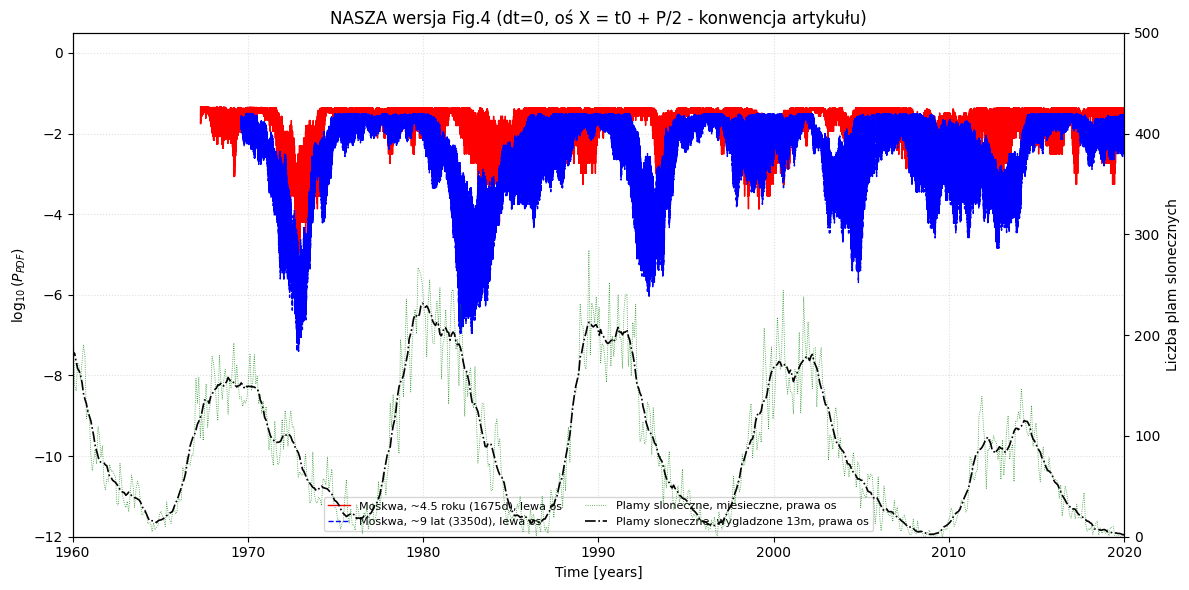

In [4]:
# KROK 3: NASZA wersja Fig.4 - ten sam uklad (log10(PPDF) po lewej, sunspot
# po prawej), ta sama kolorystyka/legenda co artykul, os X = t0+P/2.
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(curve_1675["year_center"], np.log10(curve_1675["PPDF"].clip(lower=1e-300)),
          color="red", lw=1.0, label="Moskwa, ~4.5 roku (1675d), lewa os")
ax1.plot(curve_3350["year_center"], np.log10(curve_3350["PPDF"].clip(lower=1e-300)),
          color="blue", lw=1.0, ls="--", label="Moskwa, ~9 lat (3350d), lewa os")
ax1.set_ylabel(r"$\log_{10}(P_{PDF})$")
ax1.set_ylim(-12, 0.5)
ax1.set_xlim(1960, 2020)
ax1.grid(ls=":", alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(sunspot["rok_norm"], sunspot["sunspot"], color="green", lw=0.6, ls=":", alpha=0.8,
          label="Plamy sloneczne, miesieczne, prawa os")
ax2.plot(sunspot["rok_norm"], sunspot["sunspot_smooth_13m"], color="black", lw=1.2, ls="-.",
          label="Plamy sloneczne, wygladzone 13m, prawa os")
ax2.set_ylabel("Liczba plam slonecznych")
ax2.set_ylim(0, 500)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower center", fontsize=8, ncol=2)
ax1.set_xlabel("Time [years]")
ax1.set_title("NASZA wersja Fig.4 (dt=0, oś X = t0 + P/2 - konwencja artykułu)")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/our_fig4_style_mosc.png", dpi=130)
plt.show()

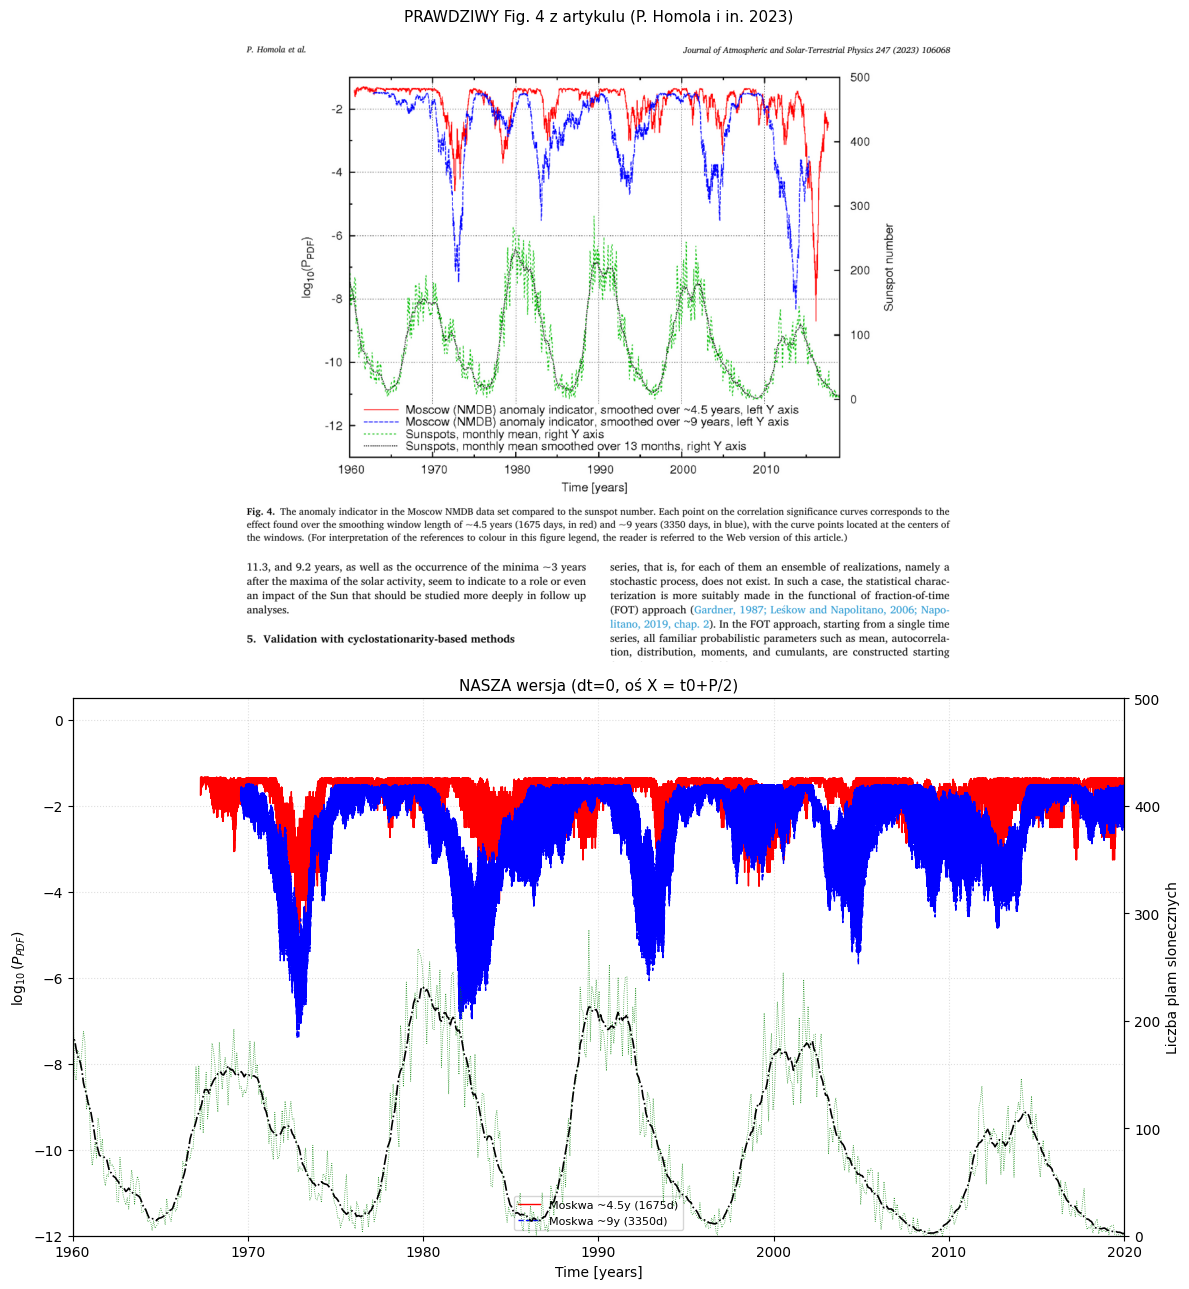

In [5]:
# KROK 4: zestawienie bok w bok - prawdziwy Fig.4 (wyciety z PDF) NAD
# NASZA wersja, te same proporcje/szerokosc, zeby ulatwic bezposrednie
# porownanie wzrokowe pozycji dolkow.
fig4_reference = imread(FIG4_REFERENCE_PATH)

fig, axes = plt.subplots(2, 1, figsize=(12, 13), gridspec_kw={"height_ratios": [1, 0.85]})

axes[0].imshow(fig4_reference)
axes[0].axis("off")
axes[0].set_title("PRAWDZIWY Fig. 4 z artykulu (P. Homola i in. 2023)", fontsize=11)

ax1 = axes[1]
ax1.plot(curve_1675["year_center"], np.log10(curve_1675["PPDF"].clip(lower=1e-300)),
          color="red", lw=1.0, label="Moskwa ~4.5y (1675d)")
ax1.plot(curve_3350["year_center"], np.log10(curve_3350["PPDF"].clip(lower=1e-300)),
          color="blue", lw=1.0, ls="--", label="Moskwa ~9y (3350d)")
ax1.set_ylabel(r"$\log_{10}(P_{PDF})$")
ax1.set_ylim(-12, 0.5)
ax1.set_xlim(1960, 2020)
ax1.grid(ls=":", alpha=0.4)
ax2 = ax1.twinx()
ax2.plot(sunspot["rok_norm"], sunspot["sunspot"], color="green", lw=0.6, ls=":", alpha=0.8)
ax2.plot(sunspot["rok_norm"], sunspot["sunspot_smooth_13m"], color="black", lw=1.2, ls="-.")
ax2.set_ylabel("Liczba plam slonecznych")
ax2.set_ylim(0, 500)
ax1.legend(loc="lower center", fontsize=8)
ax1.set_xlabel("Time [years]")
ax1.set_title("NASZA wersja (dt=0, oś X = t0+P/2)", fontsize=11)

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig4_side_by_side_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

In [6]:
# KROK 5 (tanio, ilosciowo): artykul twierdzi "minima ~3 lata po maksimum
# slonecznym". Sprawdzenie na NASZEJ (przesunietej) krzywej P=3350: nasze
# wlasne lokalne minima (find_peaks, odstep >= 8 lat, na przesunietej osi)
# vs najblizsze POPRZEDZAJACE maksimum sloneczne (na wygladzonej 13m
# krzywej plam) - odleglosc w latach do porownania z "~3 lata" artykulu.
with np.errstate(divide="ignore"):
    neglog_3350 = -np.log10(curve_3350["PPDF"].clip(lower=1e-300).to_numpy())
peak_idx, _ = find_peaks(neglog_3350, distance=8 * 365)
our_minima_shifted = curve_3350.iloc[peak_idx][["year_center", "PPDF"]].copy()
our_minima_shifted["neglog10_PPDF"] = -np.log10(our_minima_shifted["PPDF"].clip(lower=1e-300))
our_minima_shifted = our_minima_shifted.sort_values("year_center").reset_index(drop=True)

sunspot_valid = sunspot.dropna(subset=["sunspot_smooth_13m"])
max_idx, _ = find_peaks(sunspot_valid["sunspot_smooth_13m"].to_numpy(), distance=6 * 12)
solar_maxima_years = sunspot_valid["rok_norm"].to_numpy()[max_idx]
print(f"Wykryte maksima sloneczne (wygladzone 13m): {np.round(solar_maxima_years, 1)}")

rows = []
for _, row in our_minima_shifted.iterrows():
    preceding = solar_maxima_years[solar_maxima_years <= row["year_center"]]
    if len(preceding) == 0:
        continue
    nearest_max = preceding.max()
    rows.append(dict(
        nasze_minimum_rok=round(row["year_center"], 2),
        neglog10_PPDF=round(row["neglog10_PPDF"], 2),
        poprzedzajace_maksimum_sloneczne=round(nearest_max, 2),
        lat_po_maksimum=round(row["year_center"] - nearest_max, 2),
    ))
lag_table = pd.DataFrame(rows)
print("\nOdleglosc naszych minimow (P=3350, przesuniete) od poprzedzajacego maksimum slonecznego:")
print(lag_table.to_string(index=False))
print("\nArtykul: 'minima wystepuja ~3 lata po maksimum slonecznym'.")
lag_table.to_csv(f"{RESULTS_DIR}/our_minima_vs_solar_maxima.csv", index=False)

Wykryte maksima sloneczne (wygladzone 13m): [1958.2 1968.9 1980.  1989.5 2002.2 2014.3]

Odleglosc naszych minimow (P=3350, przesuniete) od poprzedzajacego maksimum slonecznego:
 nasze_minimum_rok  neglog10_PPDF  poprzedzajace_maksimum_sloneczne  lat_po_maksimum
           1972.90           7.40                           1968.87             4.02
           1982.77           6.95                           1979.96             2.81
           1992.89           6.07                           1989.46             3.44
           2004.83           5.69                           2002.20             2.62
           2012.85           4.84                           2002.20            10.64

Artykul: 'minima wystepuja ~3 lata po maksimum slonecznym'.
